# Neural Networks and Deep Learning, MDS HSE

## Homework 2. Object detection.

### General Information

### Grading and Penalties

The maximum possible grade for the assignment without bonuses is 10 points. Submitting the work after the hard deadline is not allowed.

Submitting after the soft deadline incurs a penalty of -1 point per day. Twice per semester (two modules), students are allowed to use an extension and submit by the hard deadline without penalty.

The assignment must be completed individually. “Similar” solutions will be considered plagiarism, and all involved students (including those whose work was copied) will receive no more than 0 points for the assignment. If you find a solution (or part of it) to any task from an open source, you must include a link to that source in a separate section at the end of your work (most likely you won’t be the only one who found it, so providing the link helps avoid suspicion of plagiarism).

Inefficient code implementation may negatively affect your grade. The grade may also be reduced for poorly readable code and poorly formatted plots. All answers must be accompanied by either code or comments explaining how they were obtained.

Use of generative models is allowed under the following conditions:
- The amount of code generated by such models does not exceed 30% of the total.
- You specify the model used and the prompt.
- At the end of your work, you include a **reflection on your experience using generative AI for this homework:  
  Describe how often you had to fix the code yourself or ask the model to correct something. Was it faster than writing the code on your own?

If these requirements are not met, the assignment will not be graded, and the maximum possible score is 0 points.

### About the Assignment

Shall we play Quidditch? Or maybe cards?

In this assignment, you will have to write detection architecture practically from scratch, as well as use a ready-made solution. You can choose between two datasets, which differ only in terms of images. The formats and scores are the same.

The first option is a dataset of frames from the Quidditch game in Harry Potter. If you have forgotten the rules, click [here](https://harrypotter.fandom.com/wiki/Quidditch). You will learn how to find and highlight bludgers, quaffls, and snitches in photos.

The second option is a dataset with playing cards. If you have forgotten what cards are, click [here](https://en.wikipedia.org/wiki/Playing_card). You will learn how to search for and select several types of cards in photos.

Both options contain about 300 images, and the data is stored in xml in PascalVOC format. There are slight differences, but nothing to worry about.


If you can't get the self-written detector to work at all, then after creating the datasets, you can skip to the end, where a ready-made one is taught; it will be easier with it :)

### 2023 consultation in Russian only :^( 

https://www.youtube.com/watch?v=oCwEmKW3bYg

# Notes

Hw was tested in colab only. There is no guarantee that it will work on anything else. On Windows, you will most likely encounter quite a few problems :(

## Data

Download one of the datasets that suits your taste and start working with it.
The labels are located in the xmls folder, and the images are in images.

In [ ]:
# Harry Potter -- uncomment
#!wget https://github.com/markblumenau/hw3_iad_dl/raw/main/harry/data.zip

# Cards -- uncomment
#!wget https://github.com/markblumenau/hw3_iad_dl/raw/main/cards/data.zip
import glob
import shutil
from pathlib import Path
from xml.etree import ElementTree as ET

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import ultralytics
from albumentations.pytorch.transforms import ToTensorV2
from matplotlib.patches import Rectangle
from PIL import Image
from torch import nn
from torchvision.models import ResNet50_Weights
from tqdm.notebook import tqdm

!unzip -q data.zip

# Task 1. 0.5 points.

Below is the code for a standard Dataset from the pytorch library. Dataset requires the implementation of the `__getitem__` and `__len__` methods. These methods will then be used to form batches for training. Since we will need to read from xml files, we need to add the get_xml_data function beforehand to pull up annotations by image name.

Functions are meant to receive a certain class_dict. It is present during the initialization of the dataset below. With its help, the class name can be converted to int. Further on, it is assumed that the class is passed as int.

In [ ]:
def get_xml_data(image_name, root, class_dict, xml_prefix="/xmls/"):
    # get smth like ZZZ/YYY/XXXXXX.jpg -> XXXXXX
    filename = image_name.split("/")[-1].split(".")[0]
    # read xml
    tree = ET.parse(str(root) + xml_prefix + filename + ".xml")
    treeroot = tree.getroot()
    # iterate over bboxes
    bboxes = []
    for member in treeroot.findall("object"):
        # you need: xmin ymin xmax ymax, class in dict
        # res looks like[xmin, ymin, xmax, ymax, class]
        # all is int!
        # For the cells below to work correctly, a specific sequence of coordinates is required
        # See https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/
        # We need the pascal_voc format, as later it'll be the one used.
        
        res =  ### YOUR CODE HERE ###

        bboxes.append(res)

    return bboxes

In [ ]:
class PascalDataset(torch.utils.data.Dataset):
    def __init__(self, *, transform, root="dataset", train=True, seed=42):
        self.root = Path(root)
        self.transform = transform

        assert self.root.is_dir(), f"No data at `{root}`"

        self.filenames = np.array(glob.glob(root + "/images/*"))
        with open(str(self.root) + "/class_dict", "r") as f:
            self.class_dict = eval(f.readline())

        self.class_dict_inv = {v: k for k, v in self.class_dict.items()}

        np.random.seed(seed)
        permutation = np.random.permutation(len(self.filenames))

        # Train/test split
        if train:
            self.filenames = self.filenames[
                permutation[: int(len(self.filenames) * 0.9)]
            ].tolist()
        else:
            self.filenames = self.filenames[
                permutation[int(len(self.filenames) * 0.9) :]
            ].tolist()

    def __getitem__(self, idx):
        # You need to load the image and bboxes using the filename. You added the function for loading bboxes above :)
        fname = self.filenames[idx]
        image = ### YOUR CODE HERE ###
        bboxes = ### YOUR CODE HERE ###
        
        # transform are implemented below for you
        # However, the library is particular about the input data format, so please read the previous cell carefully
        return self.transform(image=image, bboxes=bboxes)

    def __get_raw_item__(self, idx):
        fname = self.filenames[idx]
        return fname, get_xml_data(fname, self.root, self.class_dict)

    def __len__(self):
        ### YOUR CODE HERE ###
        return

Below, we define standard normalizations and resize to 512x512.

In [ ]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.augmentations.transforms.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    # Here we use the pascal_voc format
    bbox_params=dict(format="pascal_voc", min_visibility=0.3),
)

test_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.augmentations.transforms.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=dict(format="pascal_voc", min_visibility=0.5),
)

In [ ]:
train_ds = PascalDataset(root="./data/", transform=train_transform, train=True)
test_ds = PascalDataset(root="./data/", transform=test_transform, train=False)

# Task 2. 1 point.

Now that we have loaded the data, it would be good to look at it before training any models. Write a function `visualize` that takes lists of images and rectangles as input and draws these rectangles on the images.

The dataset has a class_dict_inv that will allow you to do the inverse conversion: an int containing the class to a string with the name.


Useful functions:
* [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) -- easily create multiple images in a single pyplot figure
* [ax.imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html) -- display graphs (don't forget to roll back normalization)
* [ax.text](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.text.html), [patches.Rectangle](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html) -- for drawing rectangles and text with annotations

In [ ]:
def visualize(images, bboxes):
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)

    fig, axes = plt.subplots(
        2, len(images) // 2 + len(images) % 2, figsize=(10, 8), dpi=100
    )

    for i, ax in enumerate(axes.reshape(-1)):

        ax.axis(False)

        if i >= len(images):
            break
        # Here you need to perform permute (remember where the channels are in torch and where they are in matplotlib)
        # And roll back normalization (just reverse the transformation)
        # Class names and quantities can be pulled from the dataset via train_ds.class_dict_inv

        # Here, show the image after rolling back normalization
        ax.imshow(### YOUR CODE HERE ###)

        for bbox in bboxes[i]:
        # Here you should draw your bboxes
        ### YOUR CODE HERE ###

    fig.tight_layout()
    plt.show()

You should end up with something similar to the images for the dataset with masks:

![image](https://i.imgur.com/V5TUT26.png)

In [ ]:
out = [train_ds[i] for i in range(6)]
visualize([o["image"] for o in out], [o["bboxes"] for o in out])

# Task 3. 3 points.
## YOLO-like detector

Now we need to implement a detector similar to YOLO. This is one of the simplest detectors in terms of implementation. YOLO is described in the article: [You Only Look Once: Unified, Real-Time Object Detection](https://arxiv.org/abs/1506.02640). Here we will modify and simplify it a little. We will use ResNet to extract features. The output will be a 16x16 feature map.

## Task 3.1. 1 point.

First, we need to implement the collate function. This function will allow us to customize how the batch is constructed from examples (see [pytorch docs](https://pytorch.org/docs/stable/data.html#dataloader-collate-fn) for details).

This function should take a list of rectangles as input and return a tensor of size Bx6x16x16. The first dimension is the number of examples in the batch. The second dimension is “channels,” which are explained below. Next are two spatial dimensions, which is a 16x16 grid. Let's fix the coordinate order as (y, x) for this 16x16 grid. This means that ```cy_idx, cx_idx``` go into the target in that order, see the code.

In the six “channels” we will record:
* Shifts of the bbox center relative to the beginning of the cell (a cell is a “hyperpixel” in a 16x16 image at the network output). These shifts will be recorded in the cell to which they belong. 2 channels (X, Y)
* Normalized width and height of the bbox. 2 channels (W, H)
* Confidence. We will use this to filter the neural network's confidence in the presence of a bbox in a given cell. The target contains 1 where there is a bbox and 0 otherwise. 1 channel
* Detection class (the same int obtained from the string with the name)

### Explanatory image.

It has a certain level of abstraction; for example, there should be 512 black ones, and the green one should capture 32 small black ones. But maybe it will be clearer :)

<img src="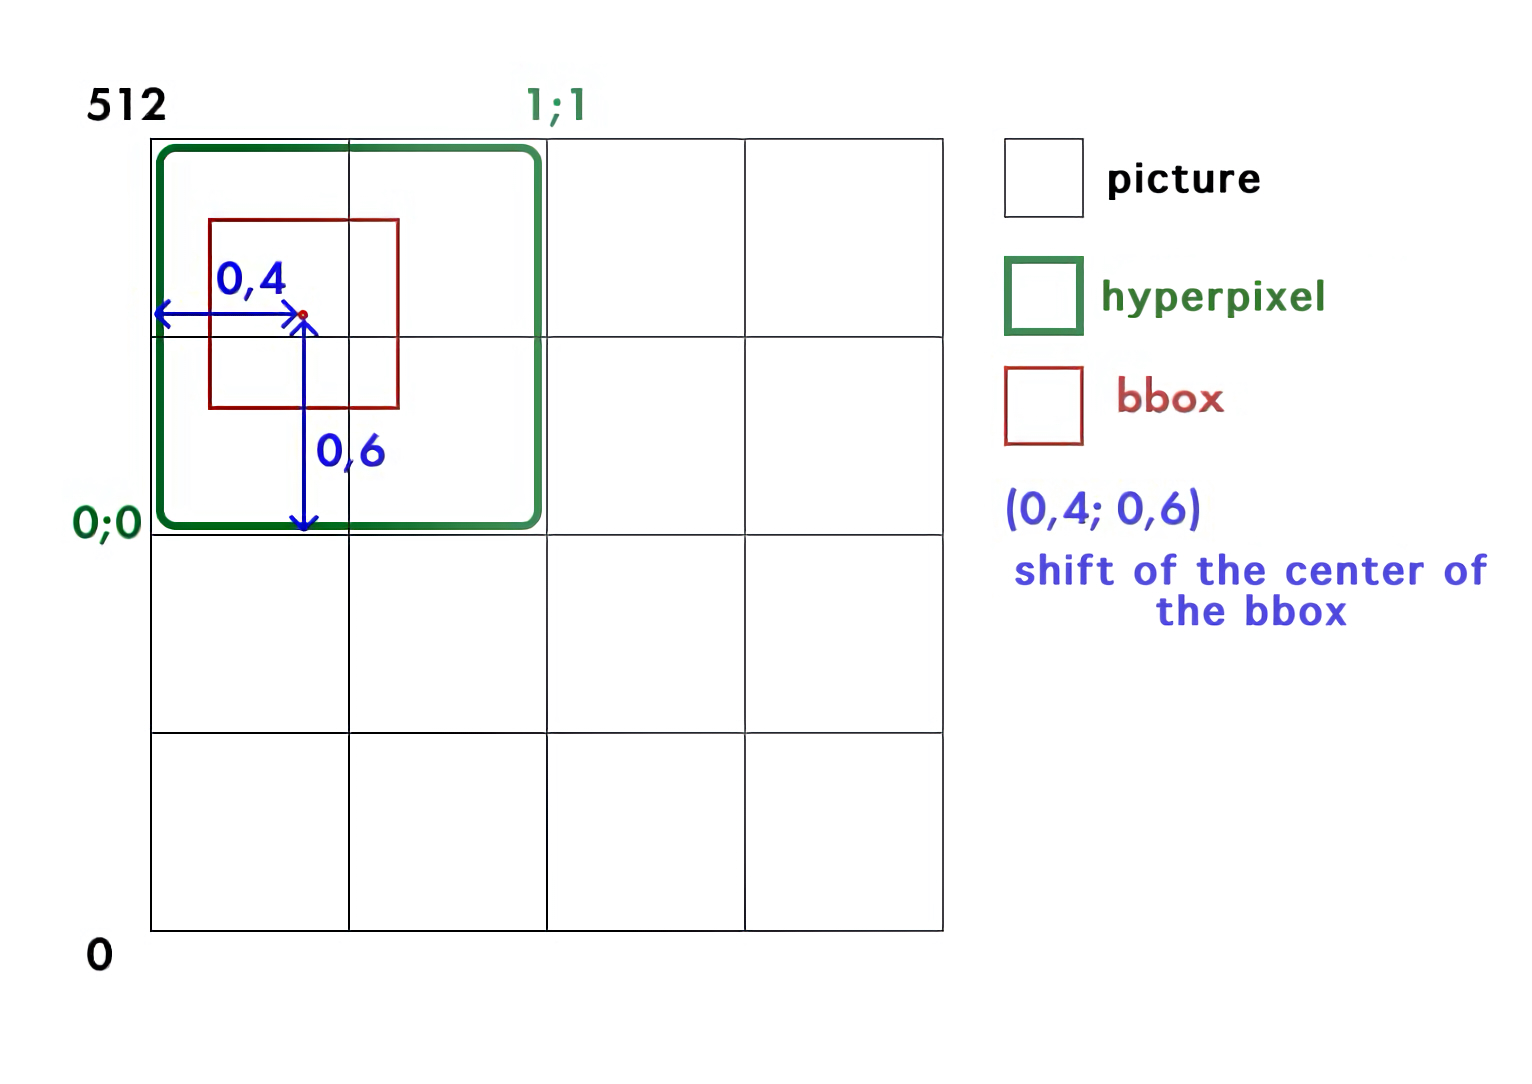
" width="1000"/>

In [ ]:
def collate_fn(batch, downsample=32):
    imgs, batch_boxes = map(list, (zip(*[(b["image"], b["bboxes"]) for b in batch])))

    imgs = torch.stack(imgs)
    b, _, h, w = imgs.shape

    target = imgs.new_zeros(b, 6, h // downsample, w // downsample)

    # Add sample index to targets
    for i, boxes in enumerate(batch_boxes):
        xmin, ymin, xmax, ymax, classes = map(
            torch.squeeze, torch.split(imgs.new_tensor(boxes), 1, dim=-1)
        )

        # Normalize the width and height by dividing by the width and height of the original image.
        x_cell =  # TODO cell size along the X axis in pixels
        y_cell =  # TODO cell size along the Y axis in pixels
        
        # The width and height of the bbox may exceed the dimensions of the hyperpixel.
        # Therefore, we normalize them by dividing by the full 512.
        w_box =  # TODO box width normalized to the size of the original image
        h_box =  # TODO box height normalized to the size of the original image

        # Calculate the coordinates of the center and the shifts
        cx =  # TODO (coordinates of the center in terms of the original coordinates)
        cy =  # TODO
        cx_idx =  # TODO (calculate the center index on the 16x16 feature map. These will be the coordinates of the pixel where we will write the box parameters)
        cy_idx =  # TODO

        cx_box =  # TODO (calculate the shifts relative to cx_idx)
        cy_box =  # TODO

        # cy_idx, then cx_idx
        target[i, :, cy_idx, cx_idx] = torch.stack(
            [cx_box, cy_box, w_box, h_box, torch.ones_like(cx_box), classes]
        )

    return {"image": imgs, "target": target}

You can check your implementation with the following function. The check is not blocking, and in theory, it is possible to write a correct solution that will not pass it.

In [ ]:
def test_collate_fn() -> None:
    target1 = [100, 200, 200, 300, 2]  # xmin, ymin, xmax, ymax, class
    target2_1 = [0, 250, 200, 300, 0]  # xmin, ymin, xmax, ymax, class
    target2_2 = [0, 100, 100, 300, 1]  # xmin, ymin, xmax, ymax, class

    result = collate_fn(
        [
            {"image": torch.rand((3, 512, 512)), "bboxes": [target1]},
            {"image": torch.rand((3, 512, 512)), "bboxes": [target2_1, target2_2]},
        ]
    )

    # Check dimensions
    assert result["image"].shape == (2, 3, 512, 512)
    assert result["target"].shape == (2, 6, 16, 16)

    # Check cell where we have bboxes
    assert np.allclose(
        result["target"][0, :, 7, 4],
        torch.tensor([22 / 32, 26 / 32, 100 / 512, 100 / 512, 1, 2]),
    )
    assert np.allclose(
        result["target"][1, :, 8, 3],
        torch.tensor([4 / 32, 19 / 32, 200 / 512, 50 / 512, 1, 0]),
    )
    assert np.allclose(
        result["target"][1, :, 6, 1],
        torch.tensor([18 / 32, 8 / 32, 100 / 512, 200 / 512, 1, 1]),
    )

    # Check that everything else is 0
    result["target"][0, :, 7, 4] = result["target"][1, :, 8, 3] = result["target"][
        1, :, 6, 1
    ] = torch.zeros(6)
    assert np.allclose(result["target"], 0)


test_collate_fn()

Below you can see an example of what a 16x16 grid looks like on the original image:

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
i = 20

img = train_ds[i]["image"].permute(1, 2, 0) * torch.tensor(std).view(
    1, 1, -1
) + torch.tensor(mean).view(1, 1, -1)
bboxes = torch.tensor(train_ds[i]["bboxes"])

ax.imshow(img)
loc = plt.matplotlib.ticker.MultipleLocator(base=32)
ax.xaxis.set_major_locator(loc)
ax.yaxis.set_major_locator(loc)
ax.grid(which="major", axis="both", linestyle="-", linewidth=3)

for bbox in bboxes:
    xmin, ymin, xmax, ymax = bbox[:-1]
    w = xmax - xmin
    h = ymax - ymin
    with_mask = bbox[-1]
    ax.add_patch(Rectangle((xmin, ymin), w, h, fill=False, color="red"))

cx = (bboxes[:, 0] + bboxes[:, 2]) / 2
cy = (bboxes[:, 1] + bboxes[:, 3]) / 2

ax.scatter(cx, cy, color="green", marker="o")

plt.show()

## Task 3.2. 0.5 points.

The output of our grid will be slightly larger than Bx6x16x16. Why?

We are solving a problem where there is more than one class. Let's recall the previous homework assignment: the target was a single number, but the output of the network contained a long vector from which we obtained the probability of belonging to a particular class. Here, it is the same, but in two dimensions: each cell of these 16x16 will have its own vector of length C, which we will use to determine the class.

Implement the inverse of the collate_fn transformation to decode the neural network output. By applying the decode_prediction function to the output of the collate function, you should get the original set of rectangles with the correct sizes and coordinates, as well as classes. Applying it to the neural network output, we should also get a set of rectangles with the correct classes. 

That is, we need to perform the operations from collate_fn in reverse, but keep in mind that the neural network output will be slightly longer, and there we need to take argmax to determine the class.

Hint: target classes come at the end. In the neural network, they will also be at the end, but there will be more than 1. You can check the number of channels of the incoming object; if it is 6, then we have a target and we need to take the value that is written in the cell. Otherwise (if there are more than 6 channels), we have the output of the neural network, and we need to take the most probable one.

In [ ]:
from typing import List


def decode_prediction(pred, upsample=32, threshold=0.7) -> List[List[List[float]]]:
    b, c, h, w = pred.shape
    img_w, img_h = w * upsample, h * upsample
    result = []
    ### YOUR CODE HERE ###
    # 3 for: one for batch
    # two for x and y coord of the grid (hyperpixels)
    # result[0] == bboxes on image 0
    # result[0][0] == first bbox on image 0
    # result[0][0] == [xmin, ymin, xmax, ymax, class]
    return result

You can check your implementation with the following function. The check is not blocking.

In [ ]:
def test_decode_predictions() -> None:
    # Apply collate_fn to some data
    target1 = [[100, 200, 200, 300, 2]]
    target2 = [[0, 250, 200, 300, 0], [0, 100, 100, 300, 1]]
    result = collate_fn(
        [
            {"image": torch.rand((3, 512, 512)), "bboxes": target1},
            {"image": torch.rand((3, 512, 512)), "bboxes": target2},
        ]
    )

    target = result["target"]
    assert target.shape == (2, 6, 16, 16)
    # In this form, the target corresponds to a search for one class - the 6th channel.
    # Let's add two more channels to test the function for multiple classes.
    target = torch.cat([target, torch.zeros(2, 2, 16, 16)], dim=1)  # Add two channels
    assert target.shape == (2, 8, 16, 16)  # Now there are 8

    target[0, 5:, 7, 4] = torch.tensor([0.5, 0.6, 0.9])  # This is class 2
    target[1, 5:, 8, 3] = torch.tensor([0.9, 0.6, 0.5])  # This is class 0
    target[1, 5:, 6, 1] = torch.tensor([0.6, 0.9, 0.5])  # This is class 1

    # Calculate the result
    actual = decode_prediction(target)
    print("Actual:  ", actual)

    # The order of boxes for target2 may vary depending on your implementation, and this is not an error.
    # Most likely, it will be like that. But if the assert fails, try swapping their places.
    expected = [target1, [target2[1], target2[0]]]
    # expected = [ target1, [ target2[0], target2[1] ] ] # <-- this answer is also correct.
    print("Expected:", expected)

    # Comparison
    assert actual == expected


test_decode_predictions()

## Task 3.3. 1 point.
Implement the model. First, apply the first 4 blocks (up to and including layer4, you can use ```list(model.children())[:-2]```). Next, add several blocks (Conv2D, BatchNorm2D, ReLU). Gradually reduce the number of channels to 5+C and the image size to 16 by 16. For example, 2048 -> 512 -> 128 -> 32 -> 5+C, where C is the number of classes in your dataset. The kernel size is 3, padding is 1. But there are many options, so try different ones! **The last layer must be a convolution.** Since all the values we predict are in the range from 0 to 1 (thanks to normalization with cells), we will apply a sigmoid after the final convolution. This will not harm the classes in this setting.

If you want to get creative, feel free to use layers with filters greater than 3 to get the right image size after the network.

In [ ]:
C =  # Number of classes in your dataset, either count them manually or pull them from the class dictionary


class Detector(nn.Module):
    def __init__(self):
        super().__init__()
        model = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)
        ### YOUR CODE HERE ###

    def forward(self, img):
        ### YOUR CODE HERE ###

        return

## Task 3.4. 0.5 points.

Implement the loss function.

To do this:
* Create a mask that will indicate the position of detected objects. It should be used with masked_select (see PyTorch docs).
* The loss is similar to the original one for Yolo V1 and consists of 4 parts (reduction=‘sum’ for all).
  - localization loss - We take the MSE of the box coordinates where there is a detected object
  - box_loss - MSE from the roots of the width and height of the bbox where there is a detected object
  - classification_loss - If there is a detected object, then its cross-entropy according to its class
  - confidence_loss - Binary cross-entropy of the fact that an object is present FOR ALL pixels. Done separately for detectable objects (weight 1) and for undetectable ones (weight 0.1, for example, since there are many more of them, but you can experiment)


* If you do the above, keep reduction in mind. Binary cross-entropy is called via BCELoss. The C parameter is used to set the number of classes. Think about how indexing depends on the C parameter and use it.

In [ ]:
def special_loss(pred, target, C=C):
    ### YOUR CODE HERE ###
    localization_loss = 
    box_loss = 
    classification_loss = 
    confidence_loss = 

    return localization_loss + box_loss + classification_loss + confidence_loss

# Task 4. 1 point.

Train your model (by writing a training cycle) and show that it works (most likely, the objects will be found in 1-2 images).

In [ ]:
loader = torch.utils.data.DataLoader(train_ds, 10, collate_fn=collate_fn)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(21)
EPOCHS =  # Harry Potter 20, Cards 15
model = Detector().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)

for e in tqdm(range(EPOCHS)):
    pbar = tqdm(loader, leave=False)
    epoch_losses = []
    for batch in pbar:
        ### YOUR CODE HERE ###


    print(f"Epoch {e} done; Train loss {np.mean(epoch_losses):.3f};")

Let's run the trained detector on test images:

In [ ]:
test_loader = torch.utils.data.DataLoader(test_ds, 6, collate_fn=collate_fn)
i = iter(test_loader)
batch = next(i)

In [ ]:
# Make a prediction and transfer the result to the CPU

### YOUR CODE HERE ###

In [ ]:
# Visualize the result. Play around with the threshold; you will most likely need to lower it to ~0.1.

### YOUR CODE HERE ###

The result is not very impressive, is it? There are many ways to improve it, the simplest of which is to add [NMS](https://paperswithcode.com/method/non-maximum-suppression#:~:text=Non%20Maximum%20Suppression%20is%20a,below%20a%20given%20probability%20bound.). If you want, you can read about YOLO v1 [here](https://arxiv.org/abs/1506.02640).

# Task 4 but better (1 point)

## Adding NMS :^)

Let's recall how the algorithm works (per class):
- Sort bboxes in descending order of confidence
- Calculate Intersection over Union (IoU) for all bboxes
- Discard all those with intersections greater than the threshold
- Continue down the list until we reach the end

In [ ]:
def NMS(bboxes, threshold):
    # TODO: make it happen
    return  # Something

In [ ]:
def decode_prediction_nms(pred, upsample=32, threshold=0.7):
    b, c, h, w = pred.shape
    img_w, img_h = w * upsample, h * upsample
    ### YOUR CODE HERE ###

    return

# Task 5. 3.5 points.

Let's tackle something simpler. We'll take a ready-made architecture, train it on our data, and see what happens.

To do this, we'll use YOLO 11 from ultralytics.

In [ ]:
!pip install ultralytics

## Task 5.1. 1.5 points.

In order to train the model with a single line, the data needs to be converted to the correct format. Yes, yes, the classic JSON conversion. You can see how to pack it correctly [here](https://roboflow.com/formats/yolov8-pytorch-txt).

In short:
* There is a .yaml file containing the paths to the folders with images, the number of classes, and their names.
* There are train valid folders (we will help you to make them), which contain two subfolders:
  - The first one is images, which contains the images.
  - The second is labels, which contains files with the same names as the images, but instead of the image extension, they need .txt, with the format as described on Roboflow.

In [ ]:
# Делаем папочки
!rm -rf train
!rm -rf valid
!mkdir -p train/images train/labels valid/images valid/labels

Implement a function that accepts annotations in their original format and returns them in the format required by YOLO 11. This should be an array of ready-made strings that can be immediately added to a file by adding \n.

Third-party tools cannot be used; you must do this yourself.

In [ ]:
def annotation2txt(bboxes, w_im, h_im):
    ### YOUR CODE HERE ###

    return

In [ ]:
# Copy the pictures into folders and create txt files.


for i in range(len(train_ds)):
    result = train_ds.__get_raw_item__(i)

    shutil.copyfile(
        result[0],
        "./train/images/" + result[0].split("/")[-1],
    )

    h_im, w_im, ch = np.array(Image.open(result[0])).shape
    with open(
        "./train/labels/" + result[0].split("/")[-1].split(".")[0] + ".txt",
        "w",
        encoding="utf8",
    ) as f:
        f.write("\n".join(annotation2txt(result[1], w_im, h_im)))

for i in range(len(test_ds)):
    result = test_ds.__get_raw_item__(i)

    shutil.copyfile(
        result[0],
        "./valid/images/" + result[0].split("/")[-1],
    )
    h_im, w_im, ch = np.array(Image.open(result[0])).shape
    with open(
        "./valid/labels/" + result[0].split("/")[-1].split(".")[0] + ".txt",
        "w",
        encoding="utf8",
    ) as f:
        f.write("\n".join(annotation2txt(result[1], w_im, h_im)))

In [ ]:
# Prepare the YAML

nc =  # Specify the number of classes. You can count them manually or use a smart method (see class_dict).
names =  # Specify the names of the classes. You can do it manually or calculate it intelligently, it is an array of strings (see class_dict).

with open("data.yaml", "w") as f:
    f.write(f"train: ../train/images
val: ../valid/images

nc: {nc}
names: {names}")

## Task 5.2. 1.5 points.

Train the smallest YOLO 11 model. The library is very user-friendly; you only need to write two lines of code. You can use a pre-trained model.

Hint: think about why you need data.yaml and what yolo11n.yaml is (feel free to Google it).

If you have NaN or Windows loss, here are some useful links (they don't cover all existing problems, but they may help you):

https://github.com/ultralytics/ultralytics/issues/1149

https://github.com/ultralytics/yolov5/issues/6907

https://stackoverflow.com/questions/75178762/i-got-nan-for-all-losses-while-training-yolov8-model

In [ ]:
### YOUR CODE HERE ###

## Task 5.3. 0.5 points.

Draw the predictions on the validation sample (at least parts of 5-10 images).

Here you can use tricks (e.g. use the parameter save=True in predict, then read them with something, draw them with matplotlib). There are better options. The default show will try to display via opencv imshow, it will not work in colab.

In [ ]:
### YOUR CODE HERE ###

## Bonus (1 point)

Implement mAP calculation for your self-written model. If you find ready-made code on GitHub, use it and provide links :)

Compare your model with YOLO11. What do you get?